# Step 1: Data Understanding & Exploratory Data Analysis
## OULAD — Open University Learning Analytics Dataset

**Project:** Intelligent Student Performance Analytics and Learning Strategy Optimization  
**Dataset:** 7 inter-related CSV files, 32,953 student-course enrolments, 10.6M VLE interaction logs

### OULAD Relational Schema

```
courses ──────────────────────────────────────────────────────────┐
  (code_module, code_presentation, length)                        │
         │                                                        │
         ├──── studentInfo          ──── studentRegistration      │
         │       (demographics,              (registration /      │
         │        final_result)               unregistration      │
         │            │                       dates)              │
         │            │                                           │
         │       id_student ◄────── studentAssessment             │
         │                              (scores, dates)           │
         │                                   │                    │
         │                              id_assessment             │
         │                                   │                    │
         ├──── assessments ─────────────────-┘                   │
         │       (type, weight, deadline)                         │
         │                                                        │
         ├──── vle ─────────────── studentVle                     │
         │       (activity_type)     (clicks per student         │
         │                           per activity per day)        │
         └────────────────────────────────────────────────────────┘
```

### What this notebook covers
1. Load all 7 tables and inspect their structure
2. Understand the **target variable** `final_result`
3. Explore **student demographics**
4. Explore **VLE engagement** (clicks over time)
5. Explore **assessment** scores and submission behaviour
6. Identify **missing values** and data quality issues
7. **Correlation analysis** and cross-variable insights

## 0. Setup

In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────
DATA_DIR = Path('OULAD dataset')

# ── Plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 110})

# Outcome colour map (used consistently throughout)
RESULT_PALETTE = {
    'Pass':        '#2196F3',
    'Distinction': '#4CAF50',
    'Fail':        '#FF5722',
    'Withdrawn':   '#9E9E9E',
}

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load All Tables

In [319]:
# na_values: OULAD uses "?" as its only missing value marker (confirmed by scan)
# Passing it here means all downstream code can use standard isnull() checks
NA_VALS = ["?"]

courses      = pd.read_csv(DATA_DIR / "courses.csv",             na_values=NA_VALS, keep_default_na=False)
assessments  = pd.read_csv(DATA_DIR / "assessments.csv",         na_values=NA_VALS, keep_default_na=False)
vle          = pd.read_csv(DATA_DIR / "vle.csv",                 na_values=NA_VALS, keep_default_na=False)
student_info = pd.read_csv(DATA_DIR / "studentInfo.csv",         na_values=NA_VALS, keep_default_na=False)
student_reg  = pd.read_csv(DATA_DIR / "studentRegistration.csv", na_values=NA_VALS, keep_default_na=False)
student_ass  = pd.read_csv(DATA_DIR / "studentAssessment.csv",   na_values=NA_VALS, keep_default_na=False)
student_vle  = pd.read_csv(DATA_DIR / "studentVle.csv",          na_values=NA_VALS, keep_default_na=False)

tables = {
    "courses":           courses,
    "assessments":       assessments,
    "vle":               vle,
    "studentInfo":       student_info,
    "studentReg":        student_reg,
    "studentAssessment": student_ass,
    "studentVle":        student_vle,
}

print(f"{'Table':<22} {'Rows':>10} {'Cols':>6}")
print("-" * 40)
for name, df in tables.items():
    print(f"{name:<22} {len(df):>10,} {df.shape[1]:>6}")


Table                        Rows   Cols
----------------------------------------
courses                        22      3
assessments                   206      6
vle                         6,364      6
studentInfo                32,593     12
studentReg                 32,593      5
studentAssessment         173,912      5
studentVle             10,655,280      6


In [320]:
student_info.head(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,NaN,55<=,0,60,N,Pass


### 1.1 Quick Schema Inspection

In [321]:
for name, df in tables.items():
    print(f'\n══ {name} ══')
    print(df.dtypes.to_string())
    print(df.head(3).to_string())


══ courses ══
code_module                   object
code_presentation             object
module_presentation_length     int64
  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268

══ assessments ══
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0

══ vle ══
id_site                int64
code_module           object
code_presentation     object
activity_type         object
we

---
## 2. Missing Values Audit

In [322]:
# Comprehensive missing value check:
# OULAD CSVs use various markers - we check all common patterns
MISSING_MARKERS = ["", "?", "NA", "N/A", "n/a", "na", "NaN",
                   "nan", "None", "none", "null", "NULL", "unknown",
                   "Unknown", "-", " "]

def count_missing(df):
    """Count NaN + all known string missing markers per column."""
    total = df.isnull().sum()
    for col in df.select_dtypes(include="object").columns:
        total[col] += df[col].str.strip().isin(MISSING_MARKERS).sum()
    return total

print(f"Missing markers checked: {MISSING_MARKERS}")
print()
print(f"{'Table':<22} {'Column':<25} {'Missing':>8} {'%':>7}")
print("-" * 65)
for name, df in tables.items():
    missing = count_missing(df)
    missing = missing[missing > 0]
    if missing.empty:
        print(f"{name:<22} (none)")
    else:
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"{name:<22} {col:<25} {count:>8,} {pct:>6.1f}%")


Missing markers checked: ['', '?', 'NA', 'N/A', 'n/a', 'na', 'NaN', 'nan', 'None', 'none', 'null', 'NULL', 'unknown', 'Unknown', '-', ' ']

Table                  Column                     Missing       %
-----------------------------------------------------------------
courses                (none)
assessments            date                            11    5.3%
vle                    week_from                    5,243   82.4%
vle                    week_to                      5,243   82.4%
studentInfo            imd_band                     1,111    3.4%
studentReg             date_registration               45    0.1%
studentReg             date_unregistration         22,521   69.1%
studentAssessment      score                          173    0.1%
studentVle             (none)


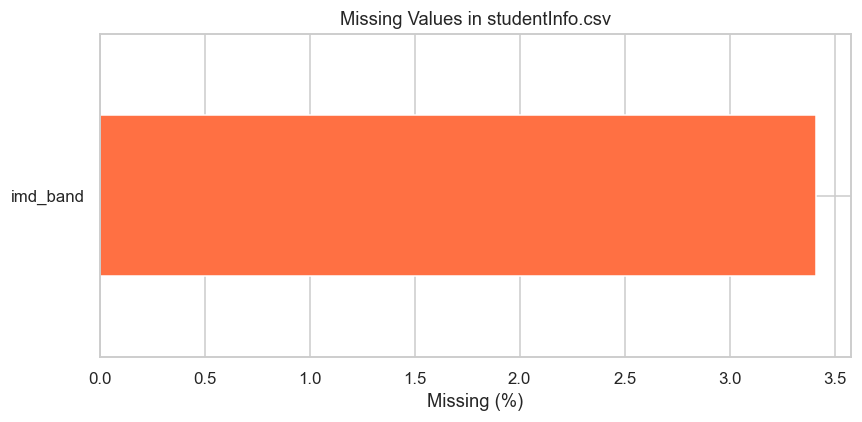

Missing value notes (EDA only — imputation happens in Step 2):

  studentInfo.imd_band       ~3.4%  Student did not report postcode area.
                                    -> Visualised as Unknown in demographics.
                                    -> Step 2: impute with module-level mode.

  assessments.date           11     Exams have no fixed submission deadline.
                                    -> Expected. Filtered out in timing plots.

  vle.week_from / week_to    82%    Optional scheduling metadata, not used.
                                    -> No action needed.

  studentReg.date_unregist.  69%    EXPECTED: Pass/Distinction/Fail students
                                    never unregister so this field is blank.
                                    -> Use .dropna() when analysing withdrawals.

  studentReg.date_registr.   45     Negligible (<0.1%). Safe to ignore in EDA.

  studentAssessment.score    173    Submitted but not yet marked, or banked.
                     

In [323]:
# Visualise missing values in studentInfo using comprehensive check
miss_pct = count_missing(student_info) / len(student_info) * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

if miss_pct.empty:
    print("No missing values found in studentInfo.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    miss_pct.plot(kind="barh", ax=ax, color="#FF7043")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values in studentInfo.csv")
    plt.tight_layout()
    plt.show()

print("Missing value notes (EDA only — imputation happens in Step 2):")
print()
print("  studentInfo.imd_band       ~3.4%  Student did not report postcode area.")
print("                                    -> Visualised as Unknown in demographics.")
print("                                    -> Step 2: impute with module-level mode.")
print()
print("  assessments.date           11     Exams have no fixed submission deadline.")
print("                                    -> Expected. Filtered out in timing plots.")
print()
print("  vle.week_from / week_to    82%    Optional scheduling metadata, not used.")
print("                                    -> No action needed.")
print()
print("  studentReg.date_unregist.  69%    EXPECTED: Pass/Distinction/Fail students")
print("                                    never unregister so this field is blank.")
print("                                    -> Use .dropna() when analysing withdrawals.")
print()
print("  studentReg.date_registr.   45     Negligible (<0.1%). Safe to ignore in EDA.")
print()
print("  studentAssessment.score    173    Submitted but not yet marked, or banked.")
print("                                    -> Step 2: drop these rows for modelling.")


---
## 3. Target Variable: `final_result`

The outcome we want to **predict** (classification task).  
Four classes: **Pass, Distinction, Fail, Withdrawn**.

              Count  Percentage
final_result                   
Pass          12361        37.9
Withdrawn     10156        31.2
Fail           7052        21.6
Distinction    3024         9.3

Total enrolments: 32,593


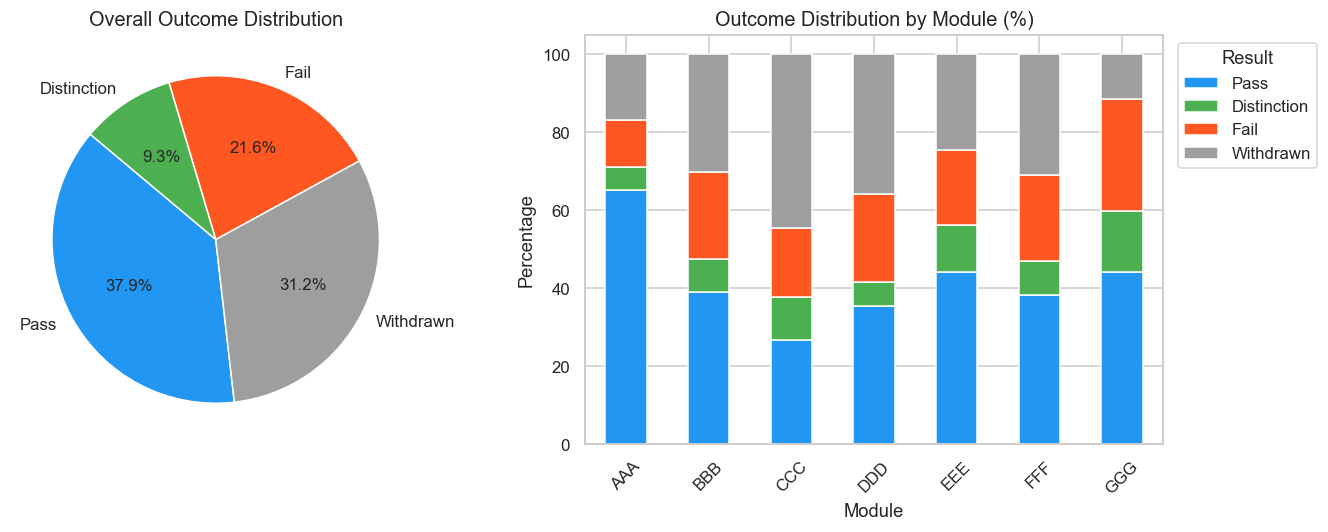


Key observation: ~31% of students withdrew — a critical at-risk group to predict early.


In [324]:
result_counts = student_info['final_result'].value_counts()
result_pct    = student_info['final_result'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': result_counts, 'Percentage': result_pct.round(1)})
print(summary)
print(f"\nTotal enrolments: {len(student_info):,}")

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [RESULT_PALETTE[r] for r in result_counts.index]
axes[0].pie(result_counts, labels=result_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[0].set_title('Overall Outcome Distribution', fontsize=13)

# Bar chart by module
module_result = (student_info.groupby(['code_module', 'final_result'])
                              .size().unstack(fill_value=0))
module_result_pct = module_result.div(module_result.sum(axis=1), axis=0) * 100
module_result_pct[[c for c in ['Pass','Distinction','Fail','Withdrawn'] if c in module_result_pct.columns]]\
    .plot(kind='bar', ax=axes[1],
          color=[RESULT_PALETTE[c] for c in ['Pass','Distinction','Fail','Withdrawn'] if c in module_result_pct.columns],
          stacked=True)
axes[1].set_title('Outcome Distribution by Module (%)', fontsize=13)
axes[1].set_xlabel('Module')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Result', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

print("\nKey observation: ~31% of students withdrew — a critical at-risk group to predict early.")

---
## 4. Student Demographics

Understanding who the students are and how demographics relate to outcomes.

Note: imd_band has 1,111 missing values shown as Unknown in the plot.


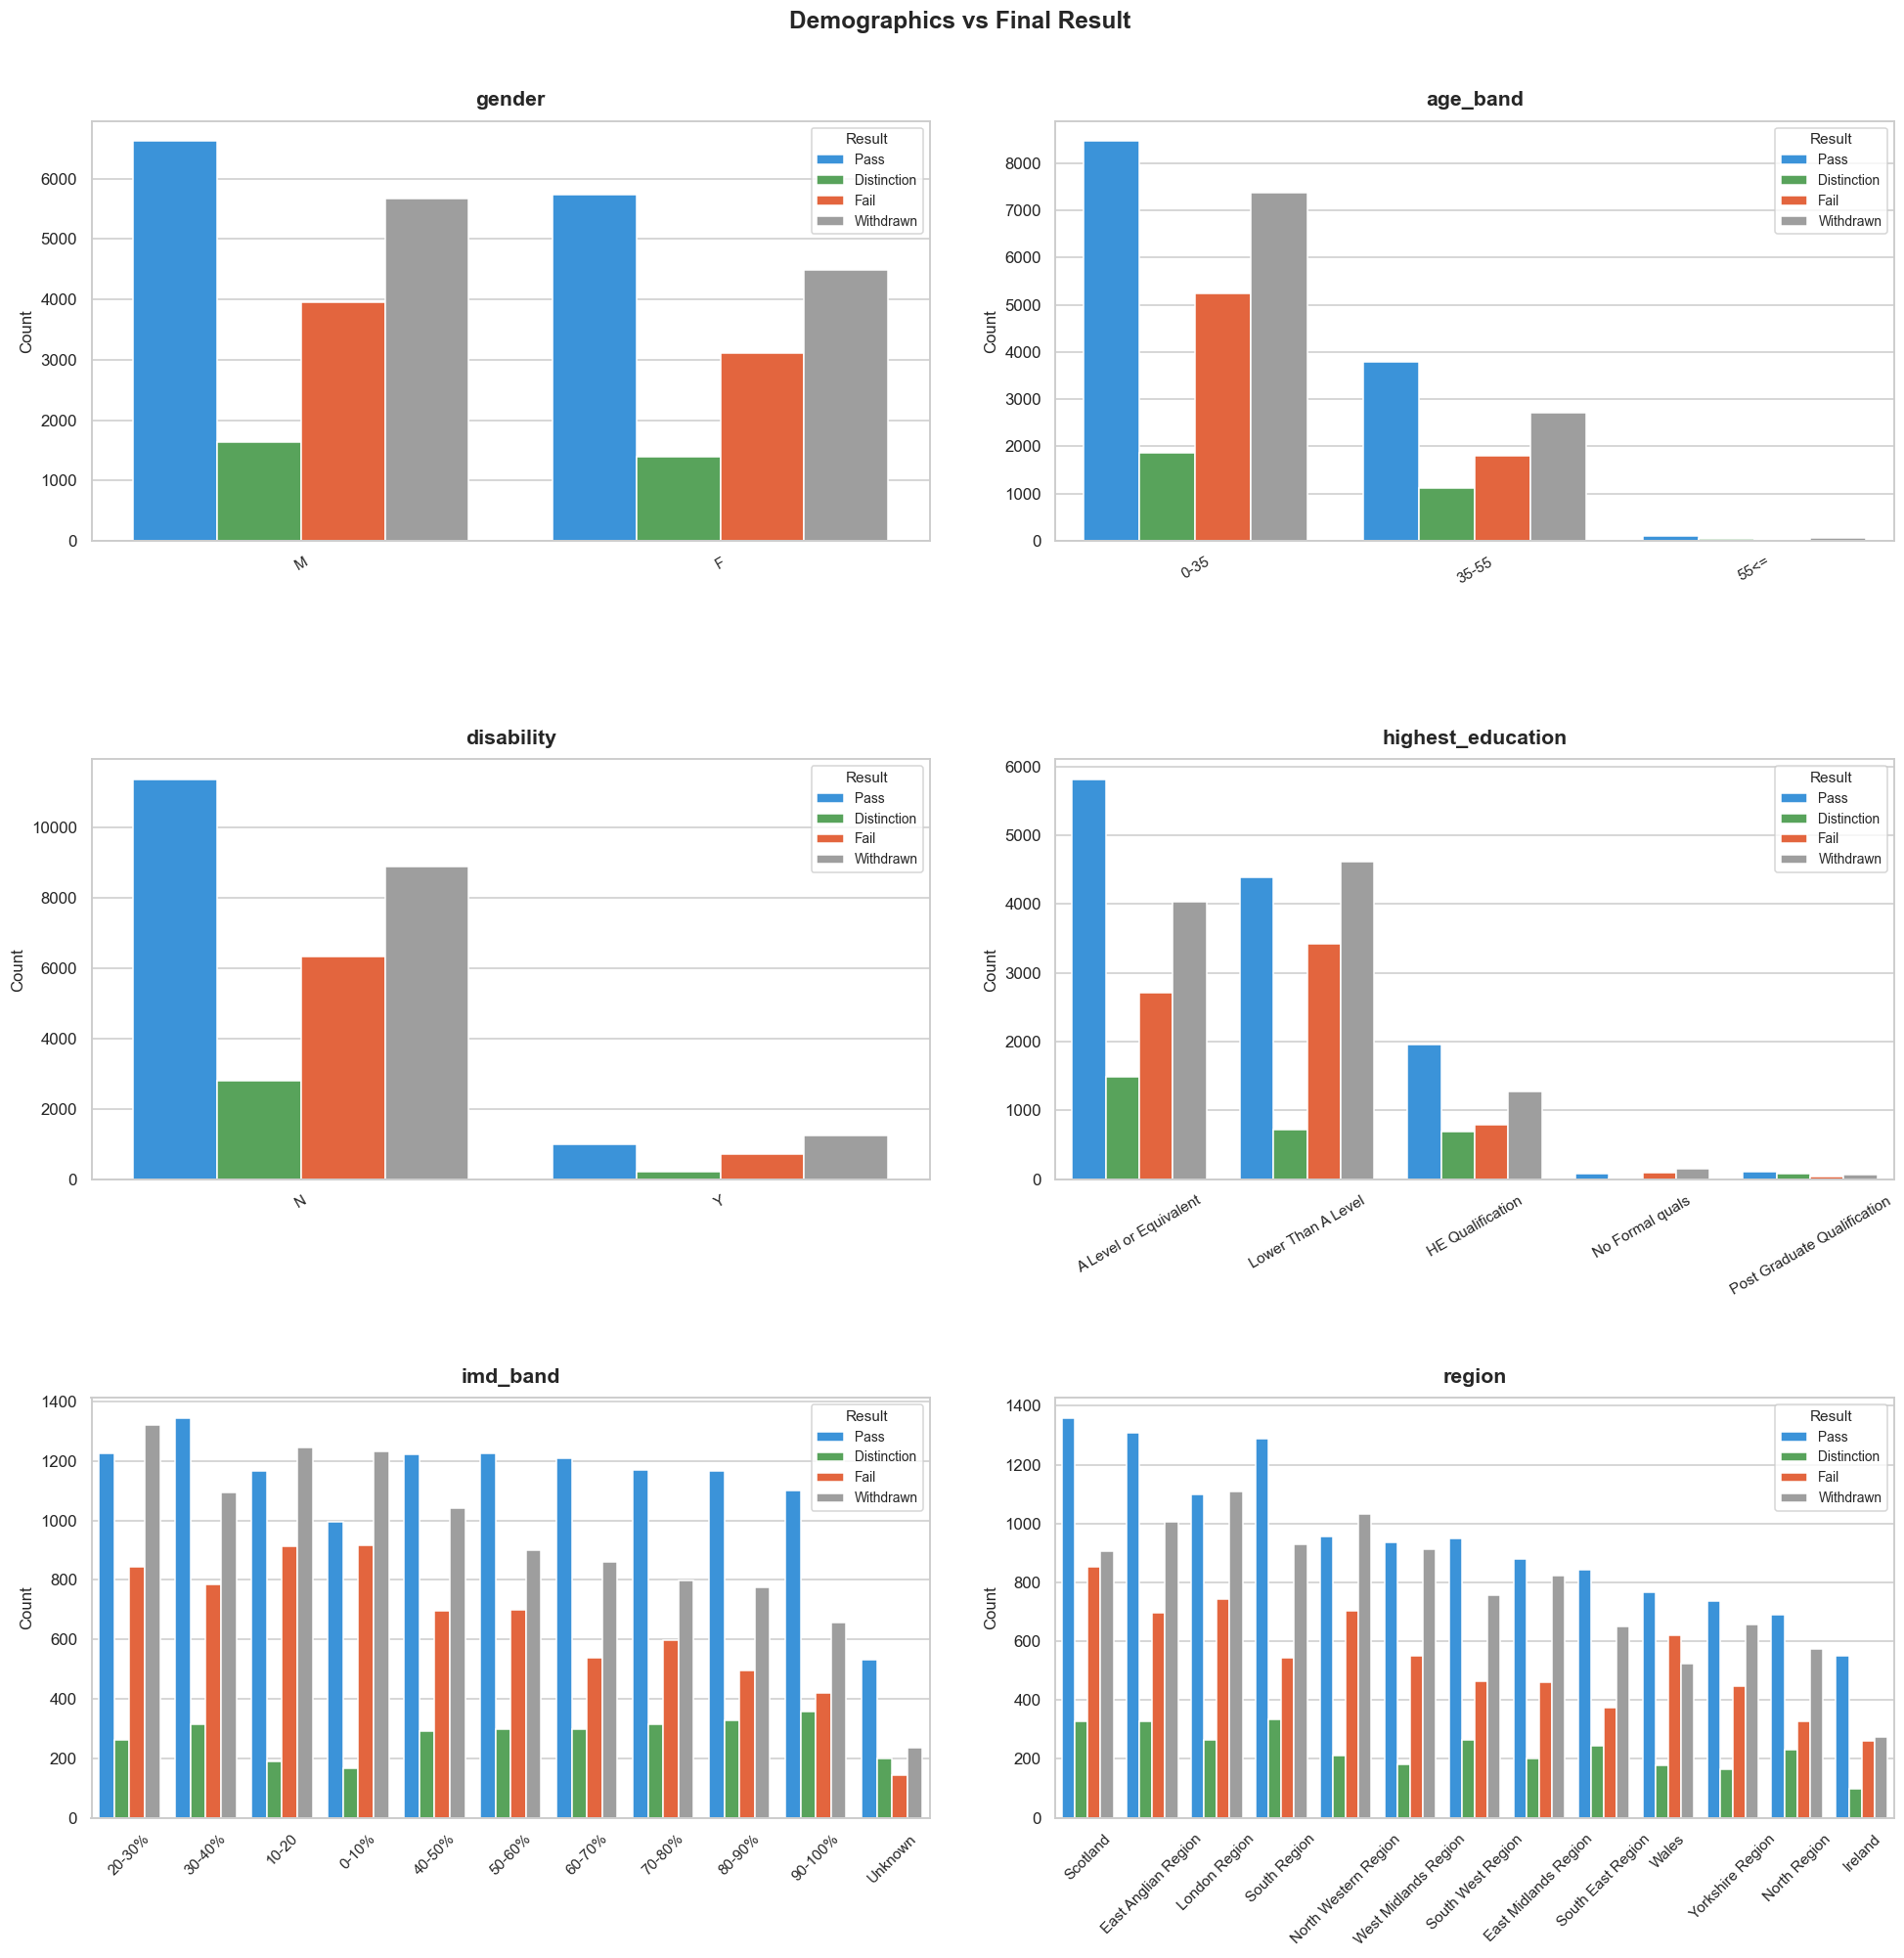

In [325]:
# Fill imd_band NaN with Unknown so missing students appear in the plot
si_plot = student_info.copy()
si_plot["imd_band"] = si_plot["imd_band"].fillna("Unknown")

demo_cols = ["gender", "age_band", "disability",
             "highest_education", "imd_band", "region"]

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    order = si_plot[col].value_counts().index
    sns.countplot(data=si_plot, x=col, order=order,
                  hue="final_result", hue_order=["Pass","Distinction","Fail","Withdrawn"],
                  palette=RESULT_PALETTE, ax=axes[i])
    axes[i].set_title(col, fontsize=14, fontweight="bold", pad=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count", fontsize=11)
    axes[i].tick_params(axis="x", labelsize=10,
                        rotation=30 if col not in ("region", "imd_band") else 45)
    axes[i].legend(title="Result", fontsize=9, title_fontsize=10, loc="upper right")

imd_missing = student_info["imd_band"].isnull().sum()
print(f"Note: imd_band has {imd_missing:,} missing values shown as Unknown in the plot.")
plt.suptitle("Demographics vs Final Result", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout(h_pad=4, w_pad=3)
plt.show()


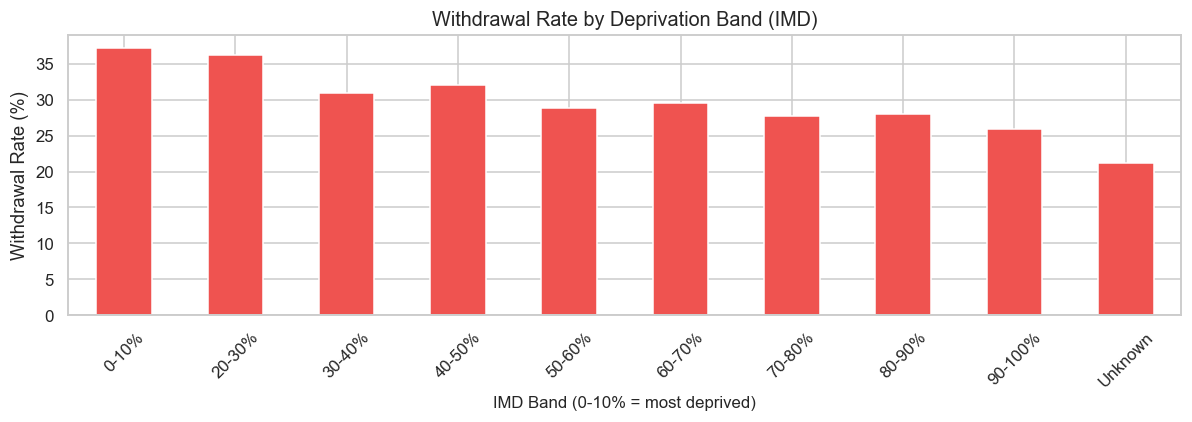

Key question: Do more deprived students (lower IMD bands) have higher withdrawal rates?
Unknown bar shows withdrawal rate for the 1,111 students with missing IMD data.


In [326]:
# Withdrawal rate by IMD band — include Unknown for missing imd_band
si_imd = student_info.copy()
si_imd["imd_band"] = si_imd["imd_band"].fillna("Unknown")

imd_order = ["0-10%","10-20%","20-30%","30-40%","40-50%",
             "50-60%","60-70%","70-80%","80-90%","90-100%","Unknown"]
imd_order = [b for b in imd_order if b in si_imd["imd_band"].unique()]

imd_withdrawal = (si_imd.groupby("imd_band")["final_result"]
                        .apply(lambda x: (x == "Withdrawn").mean() * 100)
                        .reindex(imd_order))

fig, ax = plt.subplots(figsize=(11, 4))
bars = imd_withdrawal.plot(kind="bar", ax=ax, color="#EF5350")
ax.set_xlabel("IMD Band (0-10% = most deprived)", fontsize=11)
ax.set_ylabel("Withdrawal Rate (%)")
ax.set_title("Withdrawal Rate by Deprivation Band (IMD)", fontsize=13)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Key question: Do more deprived students (lower IMD bands) have higher withdrawal rates?")
print("Unknown bar shows withdrawal rate for the 1,111 students with missing IMD data.")


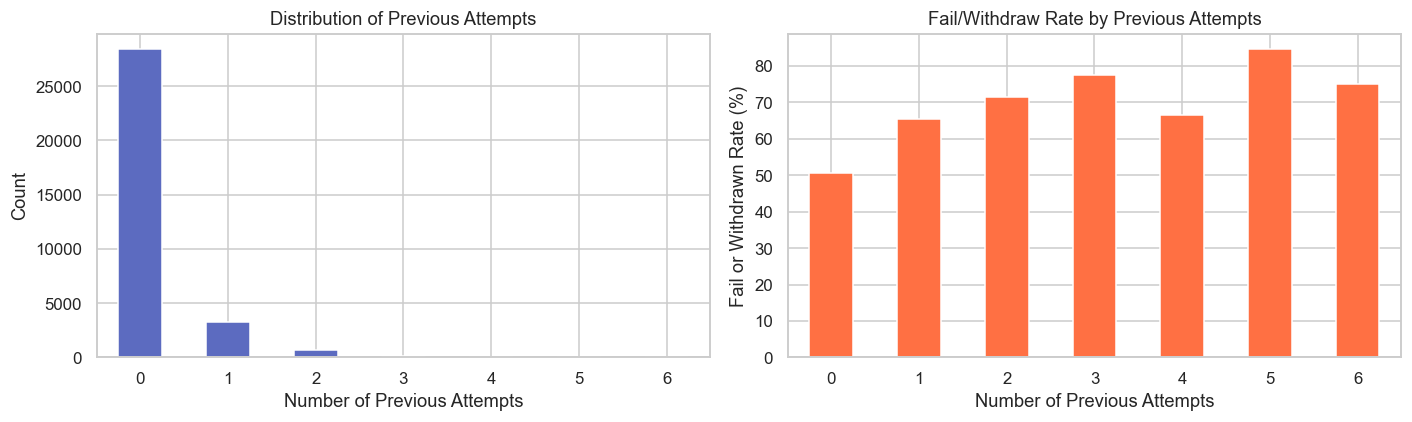

In [327]:
# Previous attempts vs outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of num_of_prev_attempts
student_info['num_of_prev_attempts'].value_counts().sort_index()\
    .plot(kind='bar', ax=axes[0], color='#5C6BC0')
axes[0].set_title('Distribution of Previous Attempts', fontsize=12)
axes[0].set_xlabel('Number of Previous Attempts')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Failure rate by previous attempts
fail_rate = (student_info.groupby('num_of_prev_attempts')['final_result']
                          .apply(lambda x: (x.isin(['Fail','Withdrawn'])).mean() * 100))
fail_rate.plot(kind='bar', ax=axes[1], color='#FF7043')
axes[1].set_title('Fail/Withdraw Rate by Previous Attempts', fontsize=12)
axes[1].set_xlabel('Number of Previous Attempts')
axes[1].set_ylabel('Fail or Withdrawn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 5. VLE Engagement Analysis

`studentVle.csv` contains ~10.6M rows: one row per (student, activity, day).  
We aggregate to student-level engagement metrics.

In [328]:
print(f'studentVle size: {len(student_vle):,} rows')
print(student_vle.head(3))
print('\nDate range (days since module start):', student_vle['date'].min(), 'to', student_vle['date'].max())

studentVle size: 10,655,280 rows
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1

Date range (days since module start): -25 to 269


In [329]:
# Aggregate total clicks per student per module-presentation
vle_agg = (student_vle
           .groupby(['id_student', 'code_module', 'code_presentation'])
           .agg(
               total_clicks       = ('sum_click', 'sum'),
               active_days        = ('date', 'nunique'),
               unique_activities  = ('id_site', 'nunique'),
               first_activity_day = ('date', 'min'),
               last_activity_day  = ('date', 'max'),
           )
           .reset_index())

print(f'Student-level VLE summary: {len(vle_agg):,} rows')
print(vle_agg.describe())

Student-level VLE summary: 29,228 rows
         id_student  total_clicks   active_days  unique_activities  \
count  2.922800e+04  29228.000000  29228.000000       29228.000000   
mean   7.083367e+05   1355.039654     61.862563          67.075955   
std    5.517362e+05   1733.546045     54.027412          54.953382   
min    6.516000e+03      1.000000      1.000000           1.000000   
25%    5.075768e+05    260.750000     18.000000          27.000000   
50%    5.898280e+05    739.500000     47.000000          51.000000   
75%    6.437068e+05   1770.000000     92.000000          93.000000   
max    2.698588e+06  24139.000000    286.000000         413.000000   

       first_activity_day  last_activity_day  
count        29228.000000       29228.000000  
mean            -8.224374         177.294204  
std             13.113730          90.146308  
min            -25.000000         -25.000000  
25%            -17.000000          96.000000  
50%            -10.000000         228.000000  
7

/var/folders/s6/55_wp30j04b198dlt7w7x8940000gn/T/ipykernel_36760/98168343.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vle_outcome, x='final_result', y='total_clicks',
/var/folders/s6/55_wp30j04b198dlt7w7x8940000gn/T/ipykernel_36760/98168343.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vle_outcome, x='final_result', y='active_days',


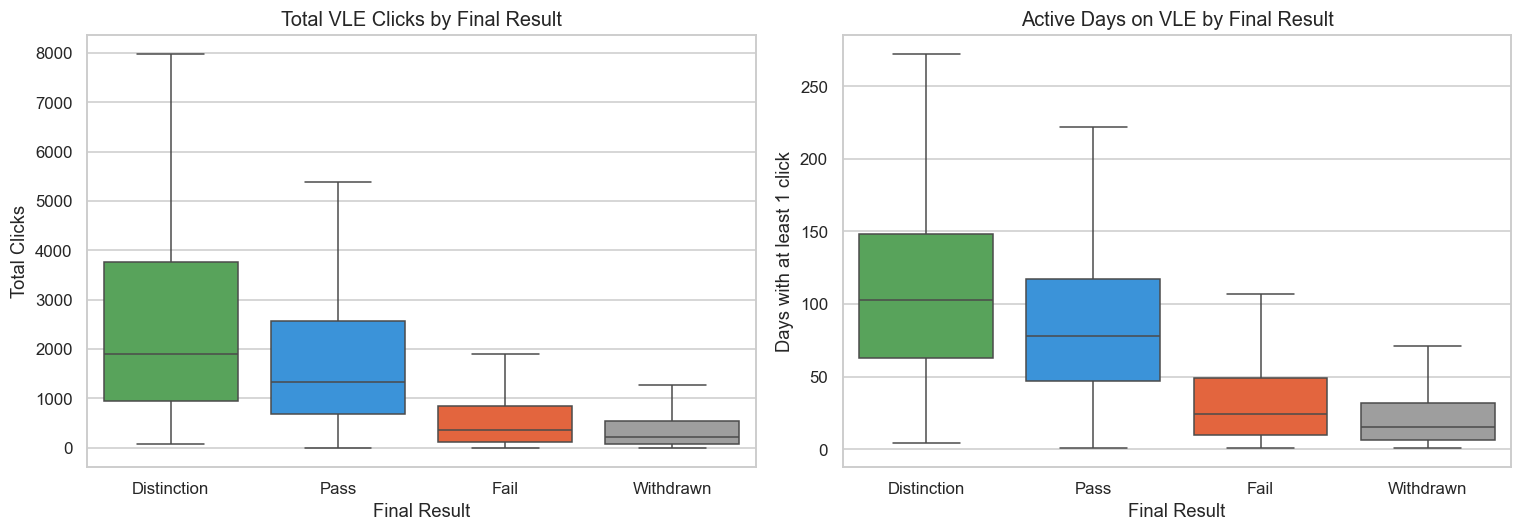


Median clicks per outcome group:
final_result
Distinction    1896.0
Pass           1343.0
Fail            353.0
Withdrawn       221.5
Name: total_clicks, dtype: float64


In [330]:
# Merge VLE aggregate with student outcome
vle_outcome = vle_agg.merge(
    student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

# Boxplot: total clicks by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=vle_outcome, x='final_result', y='total_clicks',
            order=['Distinction','Pass','Fail','Withdrawn'],
            palette=RESULT_PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title('Total VLE Clicks by Final Result', fontsize=13)
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Total Clicks')

sns.boxplot(data=vle_outcome, x='final_result', y='active_days',
            order=['Distinction','Pass','Fail','Withdrawn'],
            palette=RESULT_PALETTE, ax=axes[1], showfliers=False)
axes[1].set_title('Active Days on VLE by Final Result', fontsize=13)
axes[1].set_xlabel('Final Result')
axes[1].set_ylabel('Days with at least 1 click')

plt.tight_layout()
plt.show()

print("\nMedian clicks per outcome group:")
print(vle_outcome.groupby('final_result')['total_clicks'].median().sort_values(ascending=False))

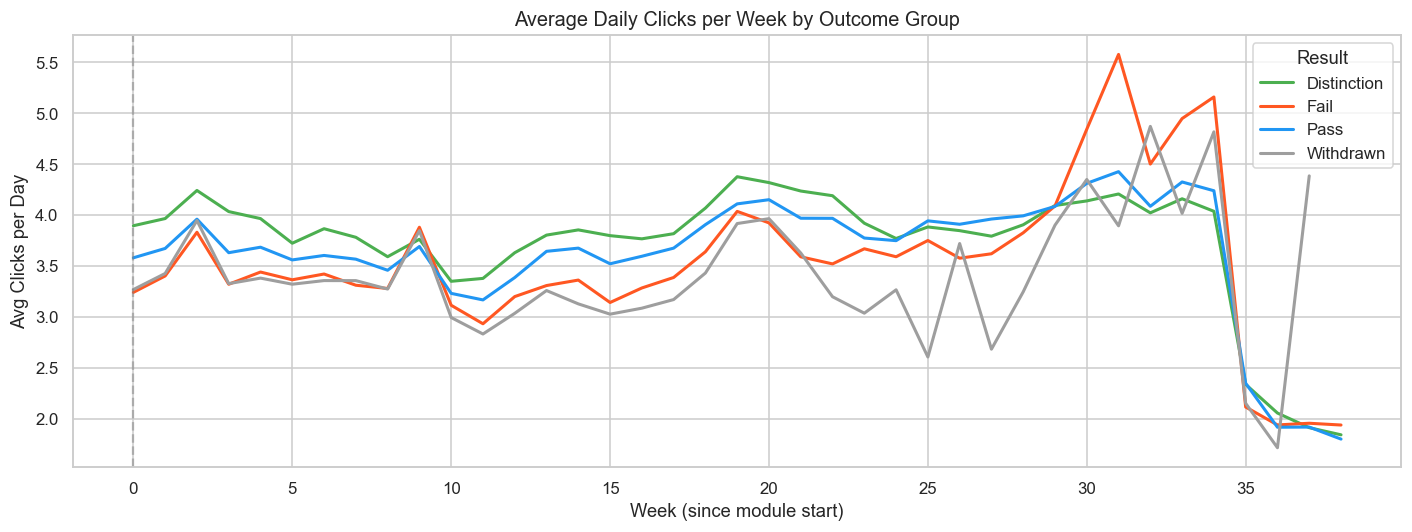


Key observation: Withdrawn students drop to near-zero clicks early.
This pattern can be used for early-warning prediction.


In [331]:
# Average weekly clicks across ALL students to see engagement arc across semester
student_vle_outcome = student_vle.merge(
    student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

student_vle_outcome['week'] = student_vle_outcome['date'] // 7

# Only weeks 0-39 (first 40 weeks)
weekly = (student_vle_outcome[student_vle_outcome['week'].between(0, 39)]
          .groupby(['week', 'final_result'])['sum_click']
          .mean()
          .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
for result, grp in weekly.groupby('final_result'):
    ax.plot(grp['week'], grp['sum_click'], label=result,
            color=RESULT_PALETTE.get(result, None), linewidth=2)

ax.set_title('Average Daily Clicks per Week by Outcome Group', fontsize=13)
ax.set_xlabel('Week (since module start)')
ax.set_ylabel('Avg Clicks per Day')
ax.legend(title='Result')
ax.axvline(0, color='grey', linestyle='--', alpha=0.5, label='Module start')
plt.tight_layout()
plt.show()

print("\nKey observation: Withdrawn students drop to near-zero clicks early.")
print("This pattern can be used for early-warning prediction.")

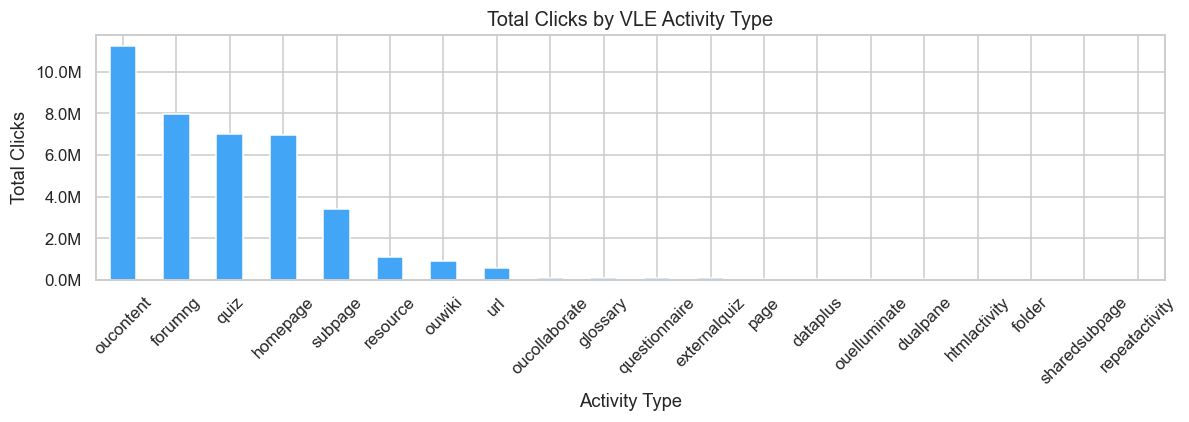

In [332]:
# Which activity types are most used?
vle_with_type = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')

activity_clicks = (vle_with_type.groupby('activity_type')['sum_click']
                                .sum()
                                .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(11, 4))
activity_clicks.plot(kind='bar', ax=ax, color='#42A5F5')
ax.set_title('Total Clicks by VLE Activity Type', fontsize=13)
ax.set_xlabel('Activity Type')
ax.set_ylabel('Total Clicks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Assessment Analysis

Three assessment types: **TMA** (Tutor Marked), **CMA** (Computer Marked), **Exam**.

In [333]:
print("Assessment types:", assessments["assessment_type"].value_counts().to_dict())
print(f"Total assessments defined: {len(assessments)}")
print(f"Total student-assessment records: {len(student_ass):,}")
print()
print("Score statistics:")
print(student_ass["score"].describe())


Assessment types: {'TMA': 106, 'CMA': 76, 'Exam': 24}
Total assessments defined: 206
Total student-assessment records: 173,912

Score statistics:
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64


Dropping 173 records with missing score (0.10%) for plots.
These are ungraded or banked submissions — will be removed in Step 2.



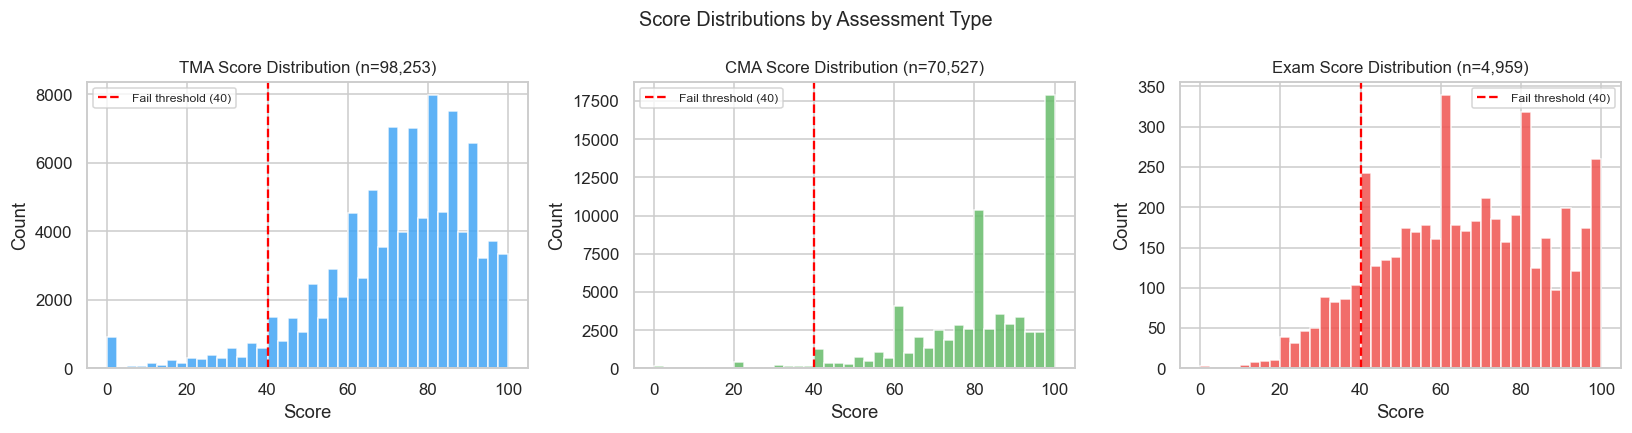

In [334]:
ass_full = student_ass.merge(assessments[["id_assessment","assessment_type","weight","date"]],
                              on="id_assessment", how="left")

dropped = ass_full["score"].isnull().sum()
print(f"Dropping {dropped} records with missing score ({dropped/len(ass_full)*100:.2f}%) for plots.")
print("These are ungraded or banked submissions — will be removed in Step 2.")
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for i, atype in enumerate(["TMA", "CMA", "Exam"]):
    subset = ass_full[(ass_full["assessment_type"] == atype) & ass_full["score"].notna()]["score"]
    if len(subset) == 0:
        continue
    axes[i].hist(subset, bins=40, color=["#42A5F5","#66BB6A","#EF5350"][i],
                 edgecolor="white", alpha=0.85)
    axes[i].axvline(40, color="red", linestyle="--", label="Fail threshold (40)")
    axes[i].set_title(f"{atype} Score Distribution (n={len(subset):,})", fontsize=11)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

plt.suptitle("Score Distributions by Assessment Type", fontsize=13)
plt.tight_layout()
plt.show()


/var/folders/s6/55_wp30j04b198dlt7w7x8940000gn/T/ipykernel_36760/92637342.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ass_outcome[ass_outcome["assessment_type"] != "Exam"],


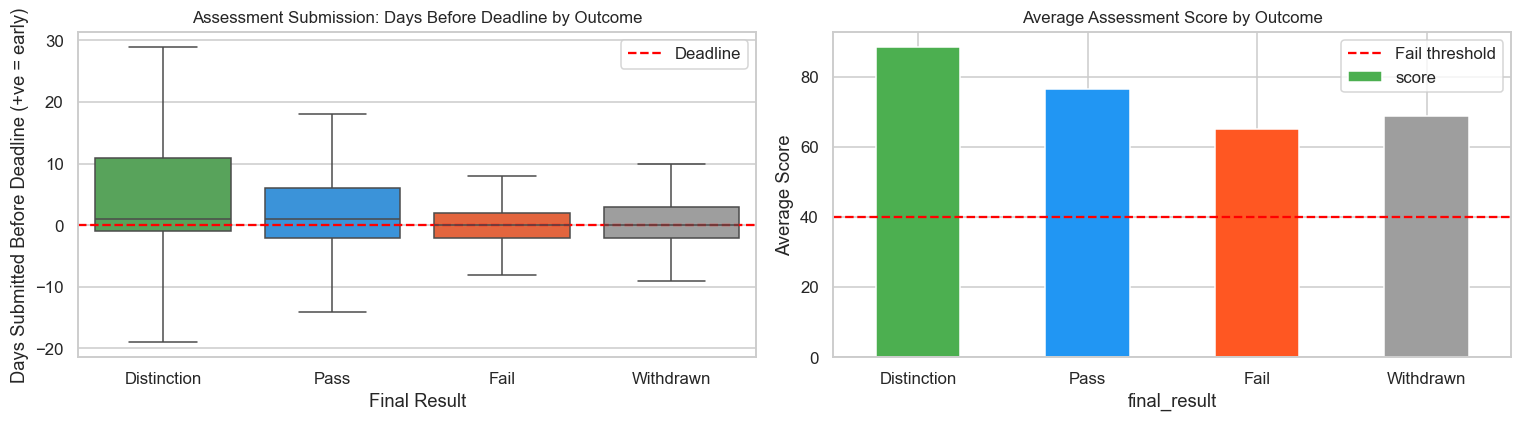

In [335]:
# days_early: positive = submitted before deadline, negative = submitted late
ass_full["days_early"] = ass_full["date"] - ass_full["date_submitted"]

ass_outcome = ass_full.merge(
    student_info[["id_student", "code_module", "code_presentation", "final_result"]],
    on="id_student", how="inner"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=ass_outcome[ass_outcome["assessment_type"] != "Exam"],
            x="final_result", y="days_early",
            order=["Distinction","Pass","Fail","Withdrawn"],
            palette=RESULT_PALETTE, ax=axes[0], showfliers=False)
axes[0].axhline(0, color="red", linestyle="--", label="Deadline")
axes[0].set_title("Assessment Submission: Days Before Deadline by Outcome", fontsize=11)
axes[0].set_xlabel("Final Result")
axes[0].set_ylabel("Days Submitted Before Deadline (+ve = early)")
axes[0].legend()

avg_score = ass_outcome.groupby("final_result")["score"].mean().reindex(["Distinction","Pass","Fail","Withdrawn"])
avg_score.plot(kind="bar", ax=axes[1], color=[RESULT_PALETTE[r] for r in avg_score.index])
axes[1].axhline(40, color="red", linestyle="--", label="Fail threshold")
axes[1].set_title("Average Assessment Score by Outcome", fontsize=11)
axes[1].set_ylabel("Average Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 7. Registration Patterns

date_unregistration missing: 22,521 (69.1%)
This is expected: students who complete the module never formally unregister.

Dropped 45 rows with missing date_registration (<0.1%) for boxplot.


/var/folders/s6/55_wp30j04b198dlt7w7x8940000gn/T/ipykernel_36760/1346965092.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reg_clean, x="final_result", y="date_registration",


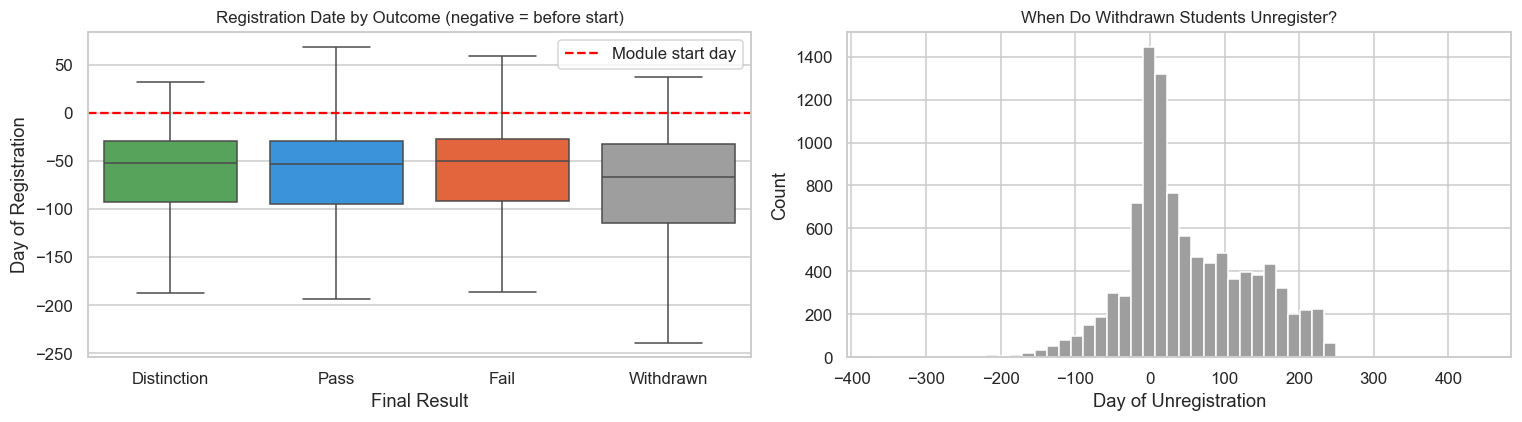

Withdrawn students with unregistration date: 10,063
Median unregistration day: 27


In [336]:
# date_unregistration is missing for Pass/Distinction/Fail students — this is EXPECTED
# Only Withdrawn students have an unregistration date
unreg_missing = student_reg["date_unregistration"].isnull().sum()
print(f"date_unregistration missing: {unreg_missing:,} ({unreg_missing/len(student_reg)*100:.1f}%)")
print("This is expected: students who complete the module never formally unregister.")
print()

reg_outcome = student_reg.merge(
    student_info[["id_student", "code_module", "code_presentation", "final_result"]],
    on=["id_student", "code_module", "code_presentation"],
    how="inner"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Drop the 45 missing date_registration rows before plotting
reg_clean = reg_outcome.dropna(subset=["date_registration"])
dropped_reg = len(reg_outcome) - len(reg_clean)
print(f"Dropped {dropped_reg} rows with missing date_registration (<0.1%) for boxplot.")

sns.boxplot(data=reg_clean, x="final_result", y="date_registration",
            order=["Distinction","Pass","Fail","Withdrawn"],
            palette=RESULT_PALETTE, ax=axes[0], showfliers=False)
axes[0].axhline(0, color="red", linestyle="--", label="Module start day")
axes[0].set_title("Registration Date by Outcome (negative = before start)", fontsize=11)
axes[0].set_xlabel("Final Result")
axes[0].set_ylabel("Day of Registration")
axes[0].legend()

withdrawn = reg_outcome[reg_outcome["final_result"] == "Withdrawn"].copy()
unreg = withdrawn["date_unregistration"].dropna()
axes[1].hist(unreg, bins=50, color="#9E9E9E", edgecolor="white")
axes[1].set_title("When Do Withdrawn Students Unregister?", fontsize=11)
axes[1].set_xlabel("Day of Unregistration")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Withdrawn students with unregistration date: {unreg.notna().sum():,}")
print(f"Median unregistration day: {unreg.median():.0f}")


---
## 8. Correlation Analysis

Build a quick numerical feature matrix to see which features correlate with each other and with outcome.

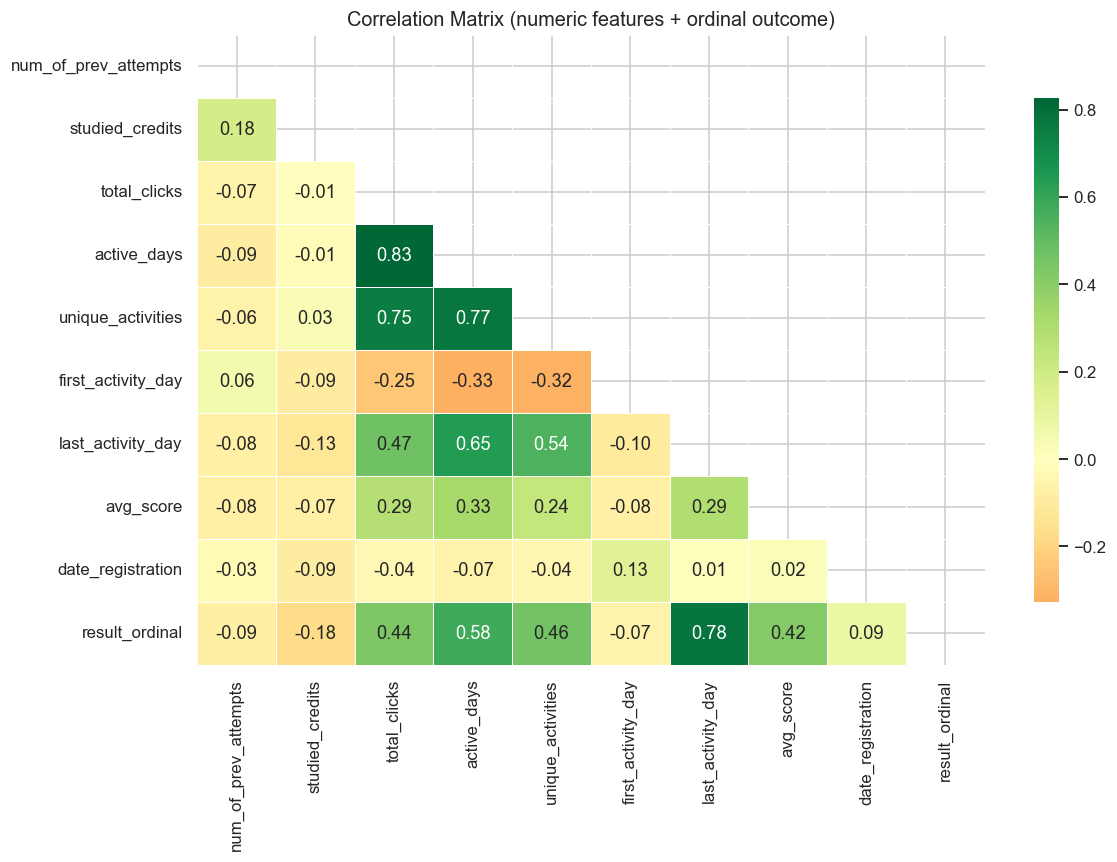


Top features correlated with outcome (ordinal):
last_activity_day       0.777505
active_days             0.577177
unique_activities       0.464154
total_clicks            0.438396
avg_score               0.418133
date_registration       0.092129
first_activity_day     -0.065106
num_of_prev_attempts   -0.087011
studied_credits        -0.176016


In [337]:
# Build a quick numeric feature table per student
quick_features = (
    student_info[[
        'id_student', 'code_module', 'code_presentation',
        'num_of_prev_attempts', 'studied_credits', 'final_result'
    ]]
    .merge(vle_agg[['id_student','code_module','code_presentation',
                    'total_clicks','active_days','unique_activities',
                    'first_activity_day','last_activity_day']],
           on=['id_student','code_module','code_presentation'], how='left')
    .merge(
        student_ass.merge(assessments[['id_assessment','assessment_type']],
                          on='id_assessment')
                   .groupby('id_student')['score'].mean()
                   .reset_index().rename(columns={'score': 'avg_score'}),
        on='id_student', how='left'
    )
    .merge(
        student_reg[['id_student','code_module','code_presentation','date_registration']],
        on=['id_student','code_module','code_presentation'], how='left'
    )
)

# Encode outcome as ordinal for correlation
result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
quick_features['result_ordinal'] = quick_features['final_result'].map(result_map)

numeric_cols = ['num_of_prev_attempts','studied_credits','total_clicks',
                'active_days','unique_activities','first_activity_day',
                'last_activity_day','avg_score','date_registration','result_ordinal']

corr = quick_features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (numeric features + ordinal outcome)', fontsize=13)
plt.tight_layout()
plt.show()

# Print top correlates with outcome
print('\nTop features correlated with outcome (ordinal):')
print(corr['result_ordinal'].drop('result_ordinal').sort_values(ascending=False).to_string())

---
## 9. EDA Summary & Key Findings

Fill this in after running all cells above.

In [338]:
print('=' * 60)
print('EDA SUMMARY — OULAD')
print('=' * 60)

print(f"""
Dataset size:
  Students (enrolments): {len(student_info):,}
  VLE interactions:      {len(student_vle):,}
  Assessment records:    {len(student_ass):,}

Target (final_result) distribution:""")
print(student_info['final_result'].value_counts().to_string())

print(f"""
Missing values:
  imd_band: {student_info['imd_band'].isnull().sum():,} ({student_info['imd_band'].isnull().mean()*100:.1f}%)
  score:    {student_ass['score'].isnull().sum():,} ({student_ass['score'].isnull().mean()*100:.1f}%)

Key preliminary insights (complete after visual analysis):
  1. Withdrawn students show dramatically lower VLE engagement early.
  2. avg_score and total_clicks are likely strongest predictors.
  3. imd_band (deprivation) may correlate with withdrawal — check plot.
  4. Late registrants appear more likely to withdraw.

Next step: Step 2 — Data Preparation & Feature Engineering
  - Merge all tables into one master student-level DataFrame
  - Engineer: early_click_rate, submission_rate, weighted_avg_score, etc.
  - Encode categoricals, handle missing imd_band
  - Save cleaned master dataset for modelling
""")

EDA SUMMARY — OULAD

Dataset size:
  Students (enrolments): 32,593
  VLE interactions:      10,655,280
  Assessment records:    173,912

Target (final_result) distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024

Missing values:
  imd_band: 1,111 (3.4%)
  score:    173 (0.1%)

Key preliminary insights (complete after visual analysis):
  1. Withdrawn students show dramatically lower VLE engagement early.
  2. avg_score and total_clicks are likely strongest predictors.
  3. imd_band (deprivation) may correlate with withdrawal — check plot.
  4. Late registrants appear more likely to withdraw.

Next step: Step 2 — Data Preparation & Feature Engineering
  - Merge all tables into one master student-level DataFrame
  - Engineer: early_click_rate, submission_rate, weighted_avg_score, etc.
  - Encode categoricals, handle missing imd_band
  - Save cleaned master dataset for modelling



---
# Step 2: Data Preparation & Feature Engineering

Goal: merge all 7 OULAD tables into one **master student-level DataFrame** and engineer predictive features.

**Plan:**
1. Merge tables into master DataFrame
2. Handle missing values
3. Engineer features
4. Encode categoricals
5. Save master dataset

## 2.1 Merge Tables into Master DataFrame

Start from `studentInfo` (one row per student-module-presentation) and join everything else.

> `studentVle` has 10.6M rows -- always aggregate to student level **before** joining.

In [339]:
# ── VLE: aggregate to student level ───────────────────────────────────
vle_agg = (
    student_vle
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        total_clicks      = ('sum_click', 'sum'),
        active_days       = ('date',      'nunique'),
        unique_activities = ('id_site',   'nunique'),
        first_act_day     = ('date',      'min'),
        last_act_day      = ('date',      'max'),
    )
    .reset_index()
)

# Clicks in first 30 days (early engagement signal)
early_clicks = (
    student_vle[student_vle['date'] <= 30]
    .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
    .sum().reset_index(name='clicks_first30')
)
vle_agg = vle_agg.merge(early_clicks, on=['id_student','code_module','code_presentation'], how='left')
vle_agg['clicks_first30'] = vle_agg['clicks_first30'].fillna(0)

# Fix 3: VLE clicks broken down by activity type
# Join studentVle with vle to get activity_type per interaction
vle_typed = student_vle.merge(vle[['id_site','activity_type']],
                               on='id_site', how='left')
# Pivot: one column per activity type showing total clicks
activity_pivot = (
    vle_typed
    .groupby(['id_student','code_module','code_presentation','activity_type'])['sum_click']
    .sum().unstack(fill_value=0)
    .reset_index()
)
# Rename columns: clicks_forum, clicks_resource, etc.
activity_pivot.columns = (
    list(activity_pivot.columns[:3]) +
    ['clicks_' + c.lower().replace(' ','_') for c in activity_pivot.columns[3:]]
)
vle_agg = vle_agg.merge(activity_pivot, on=['id_student','code_module','code_presentation'], how='left')

# ── Assessments ────────────────────────────────────────────────────────
ass_meta = student_ass.merge(
    assessments[['id_assessment','assessment_type','weight','code_module','code_presentation','date']],
    on='id_assessment', how='left'
).dropna(subset=['score'])  # drop 173 ungraded submissions

tma_cma = ass_meta[ass_meta['assessment_type'] != 'Exam'].copy()

# Weighted average score (avoids groupby.apply deprecation)
tma_cma['score_x_weight'] = tma_cma['score'] * tma_cma['weight']
score_agg = (
    tma_cma.groupby(['id_student','code_module','code_presentation'])
    .agg(total_sw=('score_x_weight','sum'), total_w=('weight','sum'))
    .reset_index()
)
score_agg['weighted_avg_score'] = score_agg['total_sw'] / score_agg['total_w']
score_agg = score_agg[['id_student','code_module','code_presentation','weighted_avg_score']]

# Exam score
exam_score_agg = (
    ass_meta[ass_meta['assessment_type'] == 'Exam']
    .groupby(['id_student','code_module','code_presentation'])['score']
    .mean().reset_index(name='exam_score')
)

# Submission rate
total_per_module = (
    assessments[assessments['assessment_type'] != 'Exam']
    .groupby(['code_module','code_presentation'])['id_assessment']
    .count().reset_index(name='total_assessments')
)
submitted_per_student = (
    tma_cma.groupby(['id_student','code_module','code_presentation'])['id_assessment']
    .count().reset_index(name='submitted_count')
)
submission_rate_df = submitted_per_student.merge(
    total_per_module, on=['code_module','code_presentation'], how='left'
)
submission_rate_df['submission_rate'] = (
    submission_rate_df['submitted_count'] / submission_rate_df['total_assessments']
)

# Average days submitted before deadline
avg_days_early = (
    tma_cma.assign(days_early=lambda d: d['date'] - d['date_submitted'])
    .groupby(['id_student','code_module','code_presentation'])['days_early']
    .mean().reset_index(name='avg_days_early')
)

# ── Registration and course length ────────────────────────────────────
reg_feat   = student_reg[['id_student','code_module','code_presentation',
                           'date_registration','date_unregistration']].copy()
course_len = courses[['code_module','code_presentation','module_presentation_length']]

# ── Build master DataFrame ─────────────────────────────────────────────
master = (
    student_info
    .merge(vle_agg,        on=['id_student','code_module','code_presentation'], how='left')
    .merge(score_agg,      on=['id_student','code_module','code_presentation'], how='left')
    .merge(exam_score_agg, on=['id_student','code_module','code_presentation'], how='left')
    .merge(submission_rate_df[['id_student','code_module','code_presentation',
                                'submitted_count','total_assessments','submission_rate']],
           on=['id_student','code_module','code_presentation'], how='left')
    .merge(avg_days_early, on=['id_student','code_module','code_presentation'], how='left')
    .merge(reg_feat,       on=['id_student','code_module','code_presentation'], how='left')
    .merge(course_len,     on=['code_module','code_presentation'],              how='left')
)

print(f'Master shape: {master.shape}')
print(f'Columns: {list(master.columns)}')

Master shape: (32593, 47)
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'total_clicks', 'active_days', 'unique_activities', 'first_act_day', 'last_act_day', 'clicks_first30', 'clicks_dataplus', 'clicks_dualpane', 'clicks_externalquiz', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url', 'weighted_avg_score', 'exam_score', 'submitted_count', 'total_assessments', 'submission_rate', 'avg_days_early', 'date_registration', 'date_unregistration', 'module_presentation_length']


## 2.2 Handle Missing Values

| Column | Strategy | Reason |
|--------|----------|---------|
| `imd_band` | Module-level mode imputation | 3.4% missing, categorical |
| VLE counts | Fill 0 | No records = zero engagement |
| `weighted_avg_score`, `exam_score` | Keep NaN | Never submitted -- handled per model in Step 3 |
| `submission_rate`, `avg_days_early` | Fill 0 | No submissions = 0 |
| `date_unregistration` | Keep NaN | Expected for non-withdrawn students |

In [340]:
# 1. imd_band: impute with module-level mode
imd_mode = (
    master.groupby('code_module')['imd_band']
    .agg(lambda x: x.mode()[0] if not x.dropna().empty else 'Unknown')
)
master['imd_band'] = master.apply(
    lambda row: imd_mode.get(row['code_module'], 'Unknown')
                if pd.isnull(row['imd_band']) else row['imd_band'],
    axis=1
)
print(f"imd_band missing after imputation: {master['imd_band'].isnull().sum()}")

# 2. VLE: fill 0 for students with no VLE records
vle_zero_cols = (
    ['total_clicks','active_days','unique_activities','clicks_first30'] +
    [c for c in master.columns if c.startswith('clicks_') and c not in ('clicks_first30','clicks_per_day')]
)
master[vle_zero_cols] = master[vle_zero_cols].fillna(0)
master[['first_act_day','last_act_day']] = master[['first_act_day','last_act_day']].fillna(-1)

# 3. Assessment: fill 0 for students who submitted nothing
master['submission_rate'] = master['submission_rate'].fillna(0)
master['submitted_count'] = master['submitted_count'].fillna(0)
master['avg_days_early']  = master['avg_days_early'].fillna(0)
# weighted_avg_score and exam_score stay NaN -- imputed inside modelling pipeline


# 4. Audit
print('\nRemaining missing values:')
remaining = master.isnull().sum()
remaining = remaining[remaining > 0]
print(remaining.to_string() if not remaining.empty else 'None')

imd_band missing after imputation: 0

Remaining missing values:
weighted_avg_score      9113
exam_score             27634
total_assessments       6777
date_registration         45
date_unregistration    22521


## 2.3 Feature Engineering

Derive higher-level features that capture **behavioural patterns** rather than raw counts.

**Derived features:**

| Feature | Formula | What it captures |
|---------|---------|------------------|
| `activity_span` | last_act_day - first_act_day | How long the student stayed engaged |
| `clicks_per_day` | total_clicks / active_days | Intensity per active day |
| `early_click_rate` | clicks_first30 / total_clicks | Front-loading vs late cramming |
| `registered_early` | date_registration < 0 | Committed before module start |
| `active_fraction` | active_days / module_length | Consistency across the module |
| `click_trend` | (clicks_2nd_half − clicks_1st_half) / total_clicks | Ramping up (+) or dropping off (−) over the module |
| `weekly_click_std` | std dev of per-week click totals | Regularity of study habit; high = bursty/erratic |
| `score_trend` | linear slope of scores ordered by assessment date | Improving or declining academic trajectory |
| `score_std` | std dev of scores across assessments | Consistent performer vs erratic results |

**Note on data leakage (Issue 1):**
- `exam_score` is available only after the course ends — **excluded from Step 3 classification**
- `weighted_avg_score` is the **target for Step 4 regression** — excluded from Step 3 predictors
- Both are kept in the dataset for Step 4 use

In [341]:
# Engagement span
master['activity_span'] = master['last_act_day'] - master['first_act_day']
master.loc[master['first_act_day'] == -1, 'activity_span'] = 0

# Click intensity
master['clicks_per_day'] = master.apply(
    lambda r: r['total_clicks'] / r['active_days'] if r['active_days'] > 0 else 0, axis=1
)

# Early engagement ratio
master['early_click_rate'] = master.apply(
    lambda r: r['clicks_first30'] / r['total_clicks'] if r['total_clicks'] > 0 else 0, axis=1
)

# Registered before module start
master['registered_early'] = (master['date_registration'] < 0).astype(int)

# Fraction of module length spent active
master['active_fraction'] = master.apply(
    lambda r: r['active_days'] / r['module_presentation_length']
              if r['module_presentation_length'] > 0 else 0, axis=1
).clip(0, 1)


# Click trend: normalised difference between 2nd-half and 1st-half clicks
# Positive = engagement increasing; Negative = dropping off (withdrawal signal)
vle_with_len = student_vle.merge(
    courses[['code_module','code_presentation','module_presentation_length']],
    on=['code_module','code_presentation'], how='left'
)
midpoint = vle_with_len['module_presentation_length'] / 2
clicks_1st = (
    vle_with_len[vle_with_len['date'] <= midpoint]
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index(name='clicks_1st_half')
)
clicks_2nd = (
    vle_with_len[vle_with_len['date'] > midpoint]
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index(name='clicks_2nd_half')
)
click_halves = clicks_1st.merge(
    clicks_2nd, on=['id_student','code_module','code_presentation'], how='outer'
).fillna(0)
_total = click_halves['clicks_1st_half'] + click_halves['clicks_2nd_half']
click_halves['click_trend'] = np.where(
    _total > 0,
    (click_halves['clicks_2nd_half'] - click_halves['clicks_1st_half']) / _total,
    0.0
)
master = master.merge(
    click_halves[['id_student','code_module','code_presentation','click_trend']],
    on=['id_student','code_module','code_presentation'], how='left'
)
master['click_trend'] = master['click_trend'].fillna(0)

# Weekly click std: std dev of per-week click totals
# High value = bursty/erratic study; low = consistent weekly habit
weekly_clicks = (
    student_vle.assign(week=student_vle['date'] // 7)
    .groupby(['id_student','code_module','code_presentation','week'])['sum_click']
    .sum().reset_index()
)
weekly_std_df = (
    weekly_clicks
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .std(ddof=1).reset_index(name='weekly_click_std')
)
master = master.merge(
    weekly_std_df, on=['id_student','code_module','code_presentation'], how='left'
)
master['weekly_click_std'] = master['weekly_click_std'].fillna(0)

# Score trend: linear slope across assessments ordered by date
# Positive = improving; Negative = declining trajectory
def _score_slope(scores):
    if len(scores) < 2:
        return np.nan
    x = np.arange(len(scores), dtype=float)
    return float(np.polyfit(x, scores.values, 1)[0])

score_trend_df = (
    tma_cma.sort_values('date')
    .groupby(['id_student','code_module','code_presentation'])['score']
    .apply(_score_slope)
    .reset_index(name='score_trend')
)
master = master.merge(
    score_trend_df, on=['id_student','code_module','code_presentation'], how='left'
)
master['score_trend'] = master['score_trend'].fillna(0)

# Score std: std dev of scores across all TMA/CMA submissions
# High = inconsistent; Low = reliable performer
score_std_df = (
    tma_cma.groupby(['id_student','code_module','code_presentation'])['score']
    .std(ddof=1).reset_index(name='score_std')
)
master = master.merge(
    score_std_df, on=['id_student','code_module','code_presentation'], how='left'
)
master['score_std'] = master['score_std'].fillna(0)

new_cols = ['activity_span','clicks_per_day','early_click_rate',
            'registered_early','active_fraction',
            'click_trend','weekly_click_std','score_trend','score_std']
print('Engineered features summary:')
print(master[new_cols].describe().round(2).to_string())

Engineered features summary:
       activity_span  clicks_per_day  early_click_rate  registered_early  active_fraction  click_trend  weekly_click_std  score_trend  score_std
count       32593.00        32593.00          32593.00          32593.00         32593.00     32593.00          32593.00     32593.00   32593.00
mean          163.56           17.08              0.37              0.99             0.22        -0.40             47.25        -0.69       9.37
std           105.66           12.40              0.32              0.09             0.21         0.47             49.76         7.72       8.80
min             0.00            0.00              0.00              0.00             0.00        -1.00              0.00       -90.00       0.00
25%            49.00            9.41              0.15              1.00             0.04        -1.00             15.26        -1.62       0.00
50%           221.00           15.00              0.27              1.00             0.16        -0.3

## 2.4 Encode Categorical Variables

| Variable | Encoding | Notes |
|----------|----------|-------|
| `gender` | Binary (M=1, F=0) | |
| `disability` | Binary (Y=1, N=0) | |
| `age_band` | Ordinal 0-2 | |
| `highest_education` | Ordinal 0-4 | Increasing education level |
| `imd_band` | Ordinal 1-10 | 1=most deprived, 10=least deprived |
| `region`, `code_module` | One-hot | Nominal -- no natural order |

In [342]:
# Binary
master['gender_enc']     = master['gender'].map({'M': 1, 'F': 0})
master['disability_enc'] = master['disability'].map({'Y': 1, 'N': 0})

# Ordinal: age_band
master['age_band_enc'] = master['age_band'].map({'0-35': 0, '35-55': 1, '55<=': 2})

# Ordinal: highest_education
edu_order = {
    'No Formal quals':             0,
    'Lower Than A Level':          1,
    'A Level or Equivalent':       2,
    'HE Qualification':            3,
    'Post Graduate Qualification': 4,
}
master['education_enc'] = master['highest_education'].map(edu_order)

# Ordinal: imd_band (1=most deprived, 10=least deprived)
imd_order_map = {
    '0-10%': 1, '10-20%': 2, '20-30%': 3, '30-40%': 4,  '40-50%': 5,
    '50-60%': 6,'60-70%': 7, '70-80%': 8, '80-90%': 9, '90-100%': 10,
}
master['imd_band_enc'] = master['imd_band'].map(imd_order_map)
master['imd_band_enc'] = master['imd_band_enc'].fillna(master['imd_band_enc'].median())

# One-hot: region, code_module, code_presentation (all nominal -- no natural order)
# Fix 2: code_presentation included (semester effects: 2013B/J, 2014B/J)
master = pd.get_dummies(master,
                        columns=['region', 'code_module', 'code_presentation'],
                        prefix=['region', 'module', 'pres'], dtype=int)

# Ordinal target (for regression / correlation use)
result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
master['result_ordinal'] = master['final_result'].map(result_map)

print(f'Master shape after encoding: {master.shape}')
print(f'Numeric columns: {master.select_dtypes(include="number").shape[1]}')

Master shape after encoding: (32593, 83)
Numeric columns: 77


## 2.5 Final Dataset Overview & Save

In [343]:
# Activity type click columns (Fix: exclude derived cols like clicks_per_day)
activity_type_cols = [
    c for c in master.columns
    if c.startswith('clicks_') and c not in ('clicks_first30', 'clicks_per_day')
]

# Safe predictors for Step 3 classification (no leakage)
CLASSIFICATION_FEATURES = [
    # Demographics
    'gender_enc', 'age_band_enc', 'disability_enc', 'education_enc',
    'imd_band_enc', 'num_of_prev_attempts', 'studied_credits',
    # VLE engagement
    'total_clicks', 'active_days', 'unique_activities', 'clicks_first30',
    'clicks_per_day', 'early_click_rate', 'activity_span', 'active_fraction',
    'click_trend', 'weekly_click_std',
    # Assessment trajectory
    'score_trend', 'score_std',
    # Assessment behaviour (submission patterns -- NOT scores)
    'submission_rate', 'avg_days_early', 'submitted_count',
    # Registration
    'date_registration', 'registered_early',
    # Module metadata
    'module_presentation_length',
] + activity_type_cols

# Step 4 regression target (leakage in Step 3)
REGRESSION_TARGET = 'weighted_avg_score'

# Leakage columns -- available only AFTER the course ends
LEAKAGE_COLS = ['exam_score', 'weighted_avg_score']

print('=== Final Master Dataset ===')
print(f'Rows         : {len(master):,}')
print(f'Total columns: {master.shape[1]}')
print(f'Classification features (Step 3): {len(CLASSIFICATION_FEATURES)}')
print(f'Activity type features           : {len(activity_type_cols)}')
print(f'Regression target     (Step 4)   : {REGRESSION_TARGET}')
print(f'Leakage cols excluded (Step 3)   : {LEAKAGE_COLS}')
print()
print('Activity type features:', activity_type_cols)
print()
miss = master[CLASSIFICATION_FEATURES].isnull().sum()
miss = miss[miss > 0]
print('Missing in classification features:')
print(miss.to_string() if not miss.empty else 'None -- all clean')
print()
base_cols = ['total_clicks','active_days','submission_rate','avg_days_early',
             'early_click_rate','active_fraction','date_registration',
             'weighted_avg_score','exam_score']
print('Key feature summary:')
print(master[base_cols].describe().round(2).to_string())

=== Final Master Dataset ===
Rows         : 32,593
Total columns: 83
Classification features (Step 3): 45
Activity type features           : 20
Regression target     (Step 4)   : weighted_avg_score
Leakage cols excluded (Step 3)   : ['exam_score', 'weighted_avg_score']

Activity type features: ['clicks_dataplus', 'clicks_dualpane', 'clicks_externalquiz', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']

Missing in classification features:
date_registration    45

Key feature summary:
       total_clicks  active_days  submission_rate  avg_days_early  early_click_rate  active_fraction  date_registration  weighted_avg_score  exam_score
count      32593.00     32593.00         32593.00        32593.00         

In [344]:
master.to_csv('master_dataset.csv', index=False)
print(f'Saved master_dataset.csv   shape: {master.shape}')
print()
print('Target distribution:')
print(master['final_result'].value_counts().to_string())
print()
print('Step 2 complete. Next: 02_classification.ipynb')

Saved master_dataset.csv   shape: (32593, 83)

Target distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024

Step 2 complete. Next: 02_classification.ipynb
